# 18 -- Fusion evaluation (score-level, confidence-weighted)

Combines the four already-trained per-modality embedders (nb14-17) via
**score-level (late) fusion** -- not a new joint multi-modal network. This
matches the project's own documented design decision ("confidence-weighted
score-level fusion, not majority voting, per-modality models") and reuses
everything nb14-17 already built rather than starting over with a harder
simultaneous-multi-modal-window architecture.

**Time alignment**: `build_windows_dataset.py`'s `build_window_grid()`
assigns `window_index`/`window_start_s`/`window_end_s` ONCE per session,
upstream of any modality-specific eligibility filtering -- confirmed by
reading the actual grid formula (`w_start = t0 + i * stride_s`). Every
modality's table is a row-subset of this same grid, so `window_index`
doesn't just correlate with elapsed time, it IS elapsed time, identically
across modalities. This notebook slides trust windows over the UNION of
available `window_index` positions per probe session (not each modality's
own separate position sequence, as nb14-17 do independently) -- giving
correct time alignment AND the same overlapping-window statistical power
as the single-modality notebooks, not a tradeoff between the two.

**Weighting schemes** (all three run in one sweep, not chosen upfront):
- `equal` -- naive average, replicates the original one-off 0.682 finding's
  methodology, now on trained embeddings instead of raw distance
- `fixed` -- per-modality weight from that modality's own negative-control
  gap (loaded from nb14-17's own output, not hardcoded)
- `dynamic` -- per-trust-window-instance weight from how many of that
  modality's own raw windows actually contributed to this instance's
  aggregate (more real evidence at this moment = more confidence)

**Combination sweep**: all 2-way and 3-way combinations of
{tap, gesture, motion} (6 combos) plus the full 4-way including typing as
a sensitivity check -- bounded, not exhaustive.

**Negative control scope note**: uses the four ALREADY-TRAINED real-label
embedding networks, frozen -- shuffles identity labels only for reference-
building and scoring, not a full per-seed retrain of all four networks
(which would mean 4 modalities x 8 seeds = 32 full trainings, expensive
for what's meant to be a bounded exploratory pass). This is a weaker but
still meaningful control: each per-modality embedding already passed its
own full retrain-per-seed negative control in nb14-17, so this tests
whether FUSION on top of already-validated embeddings still shows genuine
signal, not whether the embeddings themselves are trustworthy (already
established separately).

**Not yet executed** -- this is new code, not an adaptation of a
previously-run notebook the way nb15/16/17 were. Expect a first-run
debugging pass; flag anything that errors or looks structurally wrong
rather than assuming it is correct because it validates syntactically.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import roc_auc_score, roc_curve

%config InlineBackend.close_figures = False
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 60)
mpl.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25})

def find(*cands):
    for c in cands:
        if Path(c).exists(): return c
    raise FileNotFoundError(cands)

MOD_DIR = Path(find('data/processed/modelling', '../data/processed/modelling', '.'))
OUT_DIR = MOD_DIR.parent / 'fusion_evaluation'
OUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR = OUT_DIR / 'plots'
PLOTS_DIR.mkdir(exist_ok=True)
print(f"Outputs will be written to: {OUT_DIR.resolve()}")

MODALITIES = ['tap', 'gesture', 'motion', 'typing']

splits = pd.read_csv(find(str(MOD_DIR / 'identity_splits.csv'), 'identity_splits.csv'))

dfs = {}
for m in MODALITIES:
    p = find(str(MOD_DIR / f'{m}_windows.parquet'), f'{m}_windows.parquet')
    d = pd.read_parquet(p)
    d = d.merge(splits[['sessionId', 'role']], on='sessionId', how='inner')
    d = d.reset_index(drop=True)
    dfs[m] = d
    print(f"{m:8s}: {d.shape}, sessions={d['sessionId'].nunique()}")


Outputs will be written to: /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/fusion_evaluation
tap     : (3324, 110), sessions=96
gesture : (3324, 118), sessions=96
motion  : (3291, 41), sessions=94
typing  : (684, 169), sessions=82


In [2]:
# window_index -> (window_start_s, window_end_s) is IDENTICAL across
# modalities for a given session (same shared grid, confirmed in Section 0)
# -- so any one modality's row for a given (sessionId, window_index) gives
# the correct timing, we just need SOME row for each position that exists
# in ANY modality's table.
_position_frames = [dfs[m][['sessionId', 'window_index', 'window_start_s', 'window_end_s']] for m in MODALITIES]
position_lookup = (pd.concat(_position_frames, ignore_index=True)
                    .drop_duplicates(['sessionId', 'window_index'])
                    .set_index(['sessionId', 'window_index']))
print(f"position_lookup: {len(position_lookup)} unique (session, window_index) pairs across all modalities")

# Union of available window_index positions per PROBE session, across all
# four modalities -- this is the shared "timeline" trust windows slide
# over, not any single modality's own (sparser) position sequence.
session_positions = {}
for m in MODALITIES:
    probe = dfs[m][dfs[m]['role'] == 'probe']
    for sid, g in probe.groupby('sessionId'):
        session_positions.setdefault(sid, set()).update(g['window_index'].tolist())
session_positions = {sid: np.array(sorted(idxs)) for sid, idxs in session_positions.items()}
print(f"{len(session_positions)} probe sessions with a union position sequence built")
print(f"positions per session -- min={min(len(v) for v in session_positions.values())}, "
      f"max={max(len(v) for v in session_positions.values())}")


position_lookup: 3418 unique (session, window_index) pairs across all modalities
12 probe sessions with a union position sequence built
positions per session -- min=14, max=70


In [3]:
class Embedder(nn.Module):
    def __init__(self, n_features, embed_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 256), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.10),
            nn.Linear(128, embed_dim),
        )
    def forward(self, x):
        z = self.net(x)
        return z / z.norm(dim=1, keepdim=True).clamp_min(1e-8)

def load_modality_model(m):
    """Loads nb14/15/16/17's saved model + preprocessing for modality m.
    Preprocessing was saved as raw arrays (impute_values, scale_mean,
    scale_scale, feature_names) in <m>_preprocessing.npz, not pickled
    sklearn objects -- reconstructed here manually rather than needing
    sklearn's SimpleImputer/StandardScaler at load time."""
    mdir = Path(find(str(MOD_DIR.parent / f'{m}_embedder'), f'{m}_embedder'))
    ckpt = torch.load(mdir / f'{m}_model_seed42.pt', weights_only=False)
    feats = ckpt['feature_names']
    embed_dim = ckpt['embed_dim']
    model = Embedder(len(feats), embed_dim)
    model.load_state_dict(ckpt['state_dict'])
    model.eval()
    prep = np.load(mdir / f'{m}_preprocessing.npz', allow_pickle=True)
    assert list(prep['feature_names']) == list(feats), f"{m}: preprocessing/model feature order mismatch"
    return model, feats, prep['impute_values'], prep['scale_mean'], prep['scale_scale']

def preprocess_and_embed(model, feats, impute_values, scale_mean, scale_scale, df_m):
    X = df_m[list(feats)].to_numpy(dtype=np.float64)
    nan_mask = np.isnan(X)
    if nan_mask.any():
        X = np.where(nan_mask, impute_values, X)
    X = (X - scale_mean) / scale_scale
    with torch.no_grad():
        E = model(torch.tensor(X, dtype=torch.float32)).numpy()
    return E

models, embeddings, refs = {}, {}, {}
for m in MODALITIES:
    model, feats, impute_values, scale_mean, scale_scale = load_modality_model(m)
    E = preprocess_and_embed(model, feats, impute_values, scale_mean, scale_scale, dfs[m])
    models[m] = model
    embeddings[m] = E
    enrol_mask = (dfs[m]['role'] == 'enrol').to_numpy()
    pid_arr = dfs[m]['participantId'].to_numpy()
    refs[m] = {pid: E[enrol_mask & (pid_arr == pid)].mean(axis=0) for pid in np.unique(pid_arr[enrol_mask])}
    print(f"{m:8s}: embedded {E.shape}, {len(refs[m])} reference identities")


tap     : embedded (3324, 32), 12 reference identities
gesture : embedded (3324, 32), 12 reference identities
motion  : embedded (3291, 32), 12 reference identities
typing  : embedded (684, 32), 11 reference identities


In [4]:
def compute_metrics(y_true, scores):
    if len(np.unique(y_true)) < 2:
        return {'auc': np.nan, 'eer': np.nan, 'far_at_10pct_frr': np.nan}
    auc = roc_auc_score(y_true, scores)
    fpr, tpr, _ = roc_curve(y_true, scores)
    frr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fpr - frr)))
    eer = float((fpr[idx] + frr[idx]) / 2)
    far10 = float(np.interp(0.90, tpr, fpr))
    return {'auc': float(auc), 'eer': eer, 'far_at_10pct_frr': far10}

def score_modality_on_shared_trust(m, df_m, E, refs_m, session_positions, k_values, y_override=None):
    """Scores modality m's own windows against SHARED trust-window
    instances (defined by session_positions, the union across all four
    modalities -- see Section 2), not m's own separate position sequence
    the way nb14-17's score_probe_windows() does. trust_id is therefore
    comparable ACROSS modalities for the same (session, k, i), which is
    what makes fusing rows from different modalities at the same trust_id
    meaningful. If y_override is given (participantId -> shuffled label
    array aligned to df_m's rows), scores under those labels instead of
    the real ones -- used by the negative control in Section 8, without
    needing to retrain the embedding network itself (see Section 0 scope
    note)."""
    pid_col = df_m['participantId'].to_numpy() if y_override is None else y_override
    role_col = df_m['role'].to_numpy()
    sid_col = df_m['sessionId'].to_numpy()
    wi_col = df_m['window_index'].to_numpy()
    probe_mask = role_col == 'probe'

    m_idx = {}
    for pos, (sid, wi) in enumerate(zip(sid_col, wi_col)):
        m_idx[(sid, wi)] = pos

    rows = []
    probe_sessions = np.unique(sid_col[probe_mask])
    for sid in probe_sessions:
        sess_rows = np.where(probe_mask & (sid_col == sid))[0]
        if len(sess_rows) == 0:
            continue
        pid = pid_col[sess_rows[0]]
        pos_seq = session_positions.get(sid)
        if pos_seq is None or len(pos_seq) == 0:
            continue
        for k in k_values:
            if len(pos_seq) < k:
                continue
            for i in range(len(pos_seq) - k + 1):
                window_positions = pos_seq[i:i + k]
                lo, hi = window_positions[0], window_positions[-1]
                if (sid, lo) not in position_lookup.index or (sid, hi) not in position_lookup.index:
                    continue
                span_s = float(position_lookup.loc[(sid, hi), 'window_end_s']
                                - position_lookup.loc[(sid, lo), 'window_start_s'])
                mod_positions = [m_idx[(sid, wi)] for wi in window_positions if (sid, wi) in m_idx]
                if not mod_positions:
                    continue  # this modality has nothing in this shared trust window
                agg = E[mod_positions].mean(axis=0)
                trust_id = f'{sid}|{i}|{k}'
                for cand, ref in refs_m.items():
                    rows.append({'k': k, 'pid': pid, 'cand': cand, 'genuine': int(cand == pid),
                                 'dist': float(np.linalg.norm(agg - ref)), 'trust_id': trust_id,
                                 'span_s': span_s, 'n_windows': len(mod_positions), 'modality': m})
    return pd.DataFrame(rows)

def zscore_within_trust(df):
    if df.empty:
        return df
    df = df.copy()
    df['z'] = df.groupby('trust_id')['dist'].transform(
        lambda s: (s - s.mean()) / (s.std() if s.std() > 0 else 1))
    return df


In [5]:
K_VALUES = [1, 2, 3, 5, 8, 10, 15, 20]

_per_modality_scored = {}
for m in MODALITIES:
    raw = score_modality_on_shared_trust(m, dfs[m], embeddings[m], refs[m], session_positions, K_VALUES)
    _per_modality_scored[m] = zscore_within_trust(raw)
    print(f"{m:8s}: {len(raw)} scored rows across shared trust windows")

fused_long = pd.concat(_per_modality_scored.values(), ignore_index=True)
print(f"\nfused_long: {fused_long.shape}, modalities present: {sorted(fused_long['modality'].unique())}")
print(fused_long.groupby(['modality', 'k'])['trust_id'].nunique().unstack(0).to_string())


tap     : 25860 scored rows across shared trust windows
gesture : 25860 scored rows across shared trust windows
motion  : 26004 scored rows across shared trust windows
typing  : 11374 scored rows across shared trust windows

fused_long: (89098, 10), modalities present: ['gesture', 'motion', 'tap', 'typing']
modality  gesture  motion  tap  typing
k                                     
1             342     354  342      60
2             342     342  342      81
3             330     330  330     101
5             306     306  306     136
8             270     270  270     173
10            246     246  246     187
15            186     186  186     169
20            133     133  133     127


In [6]:
def load_fixed_weight_basis(m):
    """Fixed per-modality weight basis = that modality's own real-vs-
    shuffled negative-control gap, averaged across k, loaded from nb14-17's
    OWN output on disk -- not hardcoded, so this can't silently go stale
    the way an earlier hand-copied BASELINE_AUC dict did (see nb14/15
    session notes).

    CONFIRMED PROBLEM (first fusion run): typing's own negative control has
    as few as 1-3 clean identities per seed (often fewer seeds with any
    data at all), which forces its shuffled AUC to extreme values (0.0,
    0.003, 0.09 observed) purely from tiny comparison counts, not genuine
    anti-correlation -- this INFLATES typing's mean gap to ~0.83, nearly
    double tap/gesture/motion's ~0.35-0.46, handing it disproportionate
    fusion weight for a reason that has nothing to do with actual
    reliability. Down-weight any modality's gap by how many negative-
    control seeds it actually had data for, out of the total run --
    a modality whose gap number rests on fewer seeds gets penalised
    rather than trusted at face value."""
    mdir = Path(find(str(MOD_DIR.parent / f'{m}_embedder'), f'{m}_embedder'))
    p = mdir / f'{m}_negative_control_summary.csv'
    raw_p = mdir / f'{m}_negative_control_raw.csv'
    if not p.exists():
        print(f"WARNING: no negative control summary found for {m} at {p} -- falling back to weight 1.0")
        return 1.0
    df = pd.read_csv(p)
    gap_col = 'gap' if 'gap' in df.columns else None
    if gap_col is None:
        print(f"WARNING: {p} has no 'gap' column -- falling back to weight 1.0 for {m}")
        return 1.0
    gap = float(df[gap_col].mean())

    n_seeds_with_data = 8  # assume full coverage unless the raw file says otherwise
    if raw_p.exists():
        raw = pd.read_csv(raw_p)
        if 'seed' in raw.columns:
            n_seeds_with_data = raw['seed'].nunique()
    seed_coverage = n_seeds_with_data / 8.0  # SEEDS_CONTROL was range(8) in nb14-17
    adjusted = gap * seed_coverage
    if seed_coverage < 1.0:
        print(f"  {m}: raw gap={gap:.3f}, only {n_seeds_with_data}/8 negative-control seeds had "
              f"data -- down-weighted to {adjusted:.3f}")
    return max(adjusted, 1e-3)  # floor to avoid a zero/negative weight from a degenerate modality

FIXED_WEIGHT_BASIS = {m: load_fixed_weight_basis(m) for m in MODALITIES}
print("Fixed-weight basis per modality (mean real-vs-shuffled AUC gap across k):")
for m, w in FIXED_WEIGHT_BASIS.items():
    print(f"  {m:8s}: {w:.3f}")

def combine_scores(fused_long, modalities, weight_scheme):
    sub = fused_long[fused_long['modality'].isin(modalities)].copy()
    if sub.empty:
        return pd.DataFrame(columns=['k', 'pid', 'cand', 'genuine', 'trust_id', 'combined_z', 'span_s'])
    if weight_scheme == 'equal':
        sub['w'] = 1.0
    elif weight_scheme == 'fixed':
        sub['w'] = sub['modality'].map(FIXED_WEIGHT_BASIS)
    elif weight_scheme == 'dynamic':
        sub['w'] = sub['n_windows'].astype(float)
    else:
        raise ValueError(f"unknown weight_scheme: {weight_scheme}")

    # groupby().agg() with named aggregations, not groupby().apply()
    # returning a Series -- the latter has version-dependent behaviour
    # around as_index/include_groups that's easy to get subtly wrong on a
    # pandas version this wasn't tested against. This pattern is stable
    # back to pandas 0.25.
    sub['wz'] = sub['w'] * sub['z']
    grouped = sub.groupby(['k', 'pid', 'cand', 'trust_id', 'genuine'], as_index=False).agg(
        wz_sum=('wz', 'sum'), w_sum=('w', 'sum'),
        n_modalities_present=('modality', 'nunique'), span_s=('span_s', 'first'))
    grouped['combined_z'] = grouped['wz_sum'] / grouped['w_sum']
    return grouped[['k', 'pid', 'cand', 'trust_id', 'genuine', 'combined_z',
                     'n_modalities_present', 'span_s']]

def summarise_fused(combined, fixed_identities=None, label=''):
    if fixed_identities is not None:
        combined = combined[combined['pid'].isin(fixed_identities)]
    per_k = []
    for k, g in combined.groupby('k'):
        if g.empty:
            continue
        median_span = g.drop_duplicates('trust_id')['span_s'].median()
        per_k.append({'k': k, 'identity_set': label, 'n_probe_identities': g['pid'].nunique(),
                       'n_trust_windows': g['trust_id'].nunique(), 'median_span_s': median_span,
                       **compute_metrics(g['genuine'], -g['combined_z'])})
    return pd.DataFrame(per_k)


  typing: raw gap=0.329, only 3/8 negative-control seeds had data -- down-weighted to 0.124
Fixed-weight basis per modality (mean real-vs-shuffled AUC gap across k):
  tap     : 0.372
  gesture : 0.357
  motion  : 0.375
  typing  : 0.124


In [7]:
from itertools import combinations

CORE_MODALITIES = ['tap', 'gesture', 'motion']
COMBINATIONS = []
for r in (2, 3):
    COMBINATIONS.extend(combinations(CORE_MODALITIES, r))
COMBINATIONS.append(tuple(MODALITIES))  # full 4-way, typing sensitivity check
COMBINATIONS = [tuple(sorted(c)) for c in COMBINATIONS]
print(f"{len(COMBINATIONS)} combinations: {COMBINATIONS}")

WEIGHT_SCHEMES = ['equal', 'fixed', 'dynamic']

# Fixed identity set per combination: identities with >= max(K_VALUES)
# probe windows AND enrolled in EVERY modality in this specific
# combination (so a fused score at k=20 is never silently built from a
# probe-only-eligible-in-tap identity while claiming 4-way coverage).
def fixed_identities_for(modalities):
    sets = []
    for m in modalities:
        probe_counts = dfs[m][dfs[m]['role'] == 'probe'].groupby('participantId').size()
        eligible = set(probe_counts[probe_counts >= max(K_VALUES)].index) & set(refs[m].keys())
        sets.append(eligible)
    return set.intersection(*sets) if sets else set()

sweep_results = []
for combo in COMBINATIONS:
    fixed_ids = fixed_identities_for(combo)
    for scheme in WEIGHT_SCHEMES:
        combined = combine_scores(fused_long, combo, scheme)
        res = summarise_fused(combined, fixed_identities=None, label='all_available')
        res['combo'] = '+'.join(combo)
        res['weight_scheme'] = scheme
        res['identity_set'] = 'all_available'
        sweep_results.append(res)
        if len(fixed_ids) >= 2:
            res_fixed = summarise_fused(combined, fixed_identities=fixed_ids, label='fixed_across_k')
            res_fixed['combo'] = '+'.join(combo)
            res_fixed['weight_scheme'] = scheme
            sweep_results.append(res_fixed)

sweep_df = pd.concat(sweep_results, ignore_index=True)
print(f"sweep_df: {sweep_df.shape}")


5 combinations: [('gesture', 'tap'), ('motion', 'tap'), ('gesture', 'motion'), ('gesture', 'motion', 'tap'), ('gesture', 'motion', 'tap', 'typing')]
sweep_df: (216, 10)


k=20, fixed_across_k, ranked by AUC:
             combo weight_scheme  n_probe_identities  median_span_s   auc   eer
        motion+tap       dynamic                   8        157.500 0.970 0.066
        motion+tap         equal                   8        157.500 0.970 0.066
        motion+tap         fixed                   8        157.500 0.970 0.066
gesture+motion+tap         fixed                   8        157.500 0.967 0.104
gesture+motion+tap       dynamic                   8        157.500 0.967 0.107
gesture+motion+tap         equal                   8        157.500 0.967 0.107
    gesture+motion         fixed                   8        157.500 0.954 0.140
    gesture+motion       dynamic                   8        157.500 0.954 0.136
    gesture+motion         equal                   8        157.500 0.954 0.136
       gesture+tap         fixed                   8        157.500 0.952 0.144
       gesture+tap         equal                   8        157.500 0.951 0.145
   

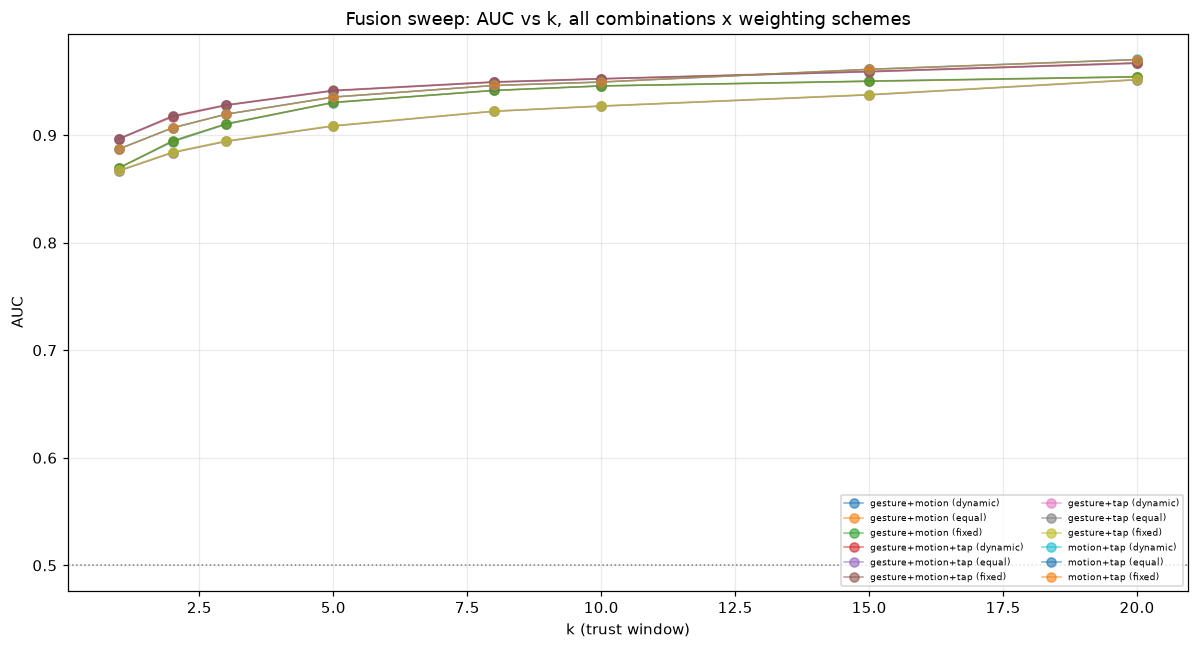

In [8]:
pd.set_option('display.max_rows', 200)
headline = sweep_df[(sweep_df['identity_set'] == 'fixed_across_k') & (sweep_df['k'] == 20)].sort_values('auc', ascending=False)
print("k=20, fixed_across_k, ranked by AUC:")
print(headline[['combo', 'weight_scheme', 'n_probe_identities', 'median_span_s', 'auc', 'eer']]
      .to_string(index=False, float_format=lambda v: f'{v:.3f}'))

print()
print("Single-modality references (from nb14-17, fixed_across_k, k=20) for comparison:")
for m in MODALITIES:
    mdir = Path(find(str(MOD_DIR.parent / f'{m}_embedder'), f'{m}_embedder'))
    manifest_path = mdir / f'{m}_manifest.json'
    if manifest_path.exists():
        import json as _json
        man = _json.load(open(manifest_path))
        auc20 = man.get('auc_real_fixed_at_k1_k10_k20', {}).get('20')
        print(f"  {m:8s}: AUC(k=20) = {auc20}")

print()
print("Original one-off finding (raw-distance baseline, pre-embedder, cited in "
      "evaluate_trust_windows.py's own docstring):")
print("  single 15s window (tap alone)              AUC 0.701")
print("  equal-weight 4-modality fusion of windows   AUC 0.682  (WORSE than tap alone)")
print("  -- this sweep re-tests that finding with TRAINED embeddings and 3 weighting")
print("     schemes rather than the untrained baseline's single equal-weight pass.")

fig, ax = plt.subplots(figsize=(11, 6))
best_per_combo = (sweep_df[(sweep_df['identity_set'] == 'fixed_across_k')]
                   .sort_values('auc', ascending=False)
                   .groupby(['combo', 'weight_scheme']))
for (combo, scheme), g in best_per_combo:
    g = g.sort_values('k')
    ax.plot(g['k'], g['auc'], marker='o', alpha=0.6, label=f'{combo} ({scheme})', lw=1)
ax.axhline(0.5, color='gray', ls=':', lw=1)
ax.set_xlabel('k (trust window)'); ax.set_ylabel('AUC')
ax.set_title('Fusion sweep: AUC vs k, all combinations x weighting schemes')
ax.legend(fontsize=6, ncol=2, loc='lower right')
plt.tight_layout()
fig.savefig(PLOTS_DIR / '01_fusion_sweep.png', dpi=150, bbox_inches='tight')
plt.show()


In [9]:
best_row = headline.iloc[0]
BEST_COMBO = tuple(best_row['combo'].split('+'))
BEST_SCHEME = best_row['weight_scheme']
print(f"Best config at k=20: combo={BEST_COMBO}, weight_scheme={BEST_SCHEME}, AUC={best_row['auc']:.3f}")

best_fixed_ids = fixed_identities_for(BEST_COMBO)
best_combined = combine_scores(fused_long, BEST_COMBO, BEST_SCHEME)
full_auc = float('nan')  # default; overwritten below if k=20 is evaluable for the best config

def leave_one_out_fused(combined, fixed_identities, k):
    base = combined[(combined['k'] == k) & combined['pid'].isin(fixed_identities)]
    results = {}
    for pid_out in sorted(fixed_identities):
        sub = base[base['pid'] != pid_out]
        if sub['genuine'].nunique() < 2:
            continue
        results[pid_out] = roc_auc_score(sub['genuine'], -sub['combined_z'])
    return results

if len(best_fixed_ids) >= 2:
    _rows_at_20 = best_combined[(best_combined['k'] == 20) & best_combined['pid'].isin(best_fixed_ids)]
    if len(_rows_at_20):
        full_auc = roc_auc_score(_rows_at_20['genuine'], -_rows_at_20['combined_z'])
        loo = leave_one_out_fused(best_combined, best_fixed_ids, 20)
        loo_df = pd.DataFrame(sorted(loo.items(), key=lambda kv: kv[1]),
                               columns=['identity_removed', 'auc_without_them'])
        loo_df['shift_from_full'] = loo_df['auc_without_them'] - full_auc
        print(f"\nFull fused AUC at k=20: {full_auc:.3f}\n")
        print(loo_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))
        worst = loo_df['shift_from_full'].abs().max()
        if worst > 0.03:
            dom = loo_df.loc[loo_df['shift_from_full'].abs().idxmax(), 'identity_removed']
            print(f"\nFLAG: removing {dom} shifts fused AUC by {loo_df.loc[loo_df['identity_removed']==dom, 'shift_from_full'].iloc[0]:+.3f}")
    else:
        print("No rows at k=20 for the best fixed identity set -- skipping leave-one-out.")
        loo, loo_df = {}, pd.DataFrame(columns=['identity_removed', 'auc_without_them', 'shift_from_full'])
else:
    print("Fewer than 2 fixed identities for the best combo -- skipping leave-one-out.")
    loo, loo_df = {}, pd.DataFrame(columns=['identity_removed', 'auc_without_them', 'shift_from_full'])


Best config at k=20: combo=('motion', 'tap'), weight_scheme=dynamic, AUC=0.970

Full fused AUC at k=20: 0.970

identity_removed  auc_without_them  shift_from_full
         p3M6E7Z             0.931           -0.039
         p95MPVX             0.967           -0.003
         p3YDMHG             0.970           -0.001
         pNDG8LJ             0.972            0.002
         pWS9VTN             0.974            0.004
         pH3S4X4             0.975            0.005
         pAFQRTM             0.976            0.006
         pUNKH7L             0.977            0.007

FLAG: removing p3M6E7Z shifts fused AUC by -0.039


In [10]:
def shuffle_labels_shared(dfs, seed):
    """ONE shuffle mapping applied identically across all four modality
    tables (keyed by sessionId), not independent per-modality shuffles --
    fusing four INDEPENDENTLY shuffled label sets would scramble any
    cross-modal consistency even further than intended and wouldn't
    isolate what the control is meant to test (whether fusion of frozen,
    already-real embeddings still shows genuine signal once identity
    labels are meaningless)."""
    rng = np.random.default_rng(seed)
    all_sessions = pd.concat([d[['sessionId', 'participantId']] for d in dfs.values()], ignore_index=True)
    sess_pid = all_sessions.drop_duplicates('sessionId').set_index('sessionId')['participantId']
    mapping = dict(zip(sess_pid.index, rng.permutation(sess_pid.values)))
    return mapping

def filter_leaked_identities_fused(mapping, dfs, fixed_ids, modalities):
    """Same leak check as nb14-17's filter_leaked_identities, generalised
    across whichever modalities are in this combo: drops a fake identity
    if ANY real participant appears in both its enrol and probe windows
    in ANY of the combo's modalities."""
    clean, dropped = set(), []
    for fake_pid in fixed_ids:
        e_true, p_true = set(), set()
        for m in modalities:
            d = dfs[m]
            shuf = d['sessionId'].map(mapping)
            e_true |= set(d.loc[(d['role'] == 'enrol') & (shuf == fake_pid), 'participantId'])
            p_true |= set(d.loc[(d['role'] == 'probe') & (shuf == fake_pid), 'participantId'])
        if not e_true or not p_true:
            continue
        overlap = e_true & p_true
        if overlap:
            dropped.append((fake_pid, sorted(overlap)))
            continue
        clean.add(fake_pid)
    return clean, dropped

SEEDS_CONTROL = list(range(8))
control_rows = []
for seed in SEEDS_CONTROL:
    mapping = shuffle_labels_shared(dfs, seed)
    y_shuf_by_modality = {m: dfs[m]['sessionId'].map(mapping).to_numpy() for m in MODALITIES}

    _per_modality_shuf = {}
    for m in MODALITIES:
        raw = score_modality_on_shared_trust(m, dfs[m], embeddings[m], refs[m], session_positions,
                                              K_VALUES, y_override=y_shuf_by_modality[m])
        _per_modality_shuf[m] = zscore_within_trust(raw)
    fused_long_shuf = pd.concat(_per_modality_shuf.values(), ignore_index=True)

    for combo in COMBINATIONS:
        combined_shuf = combine_scores(fused_long_shuf, combo, BEST_SCHEME)
        if combined_shuf.empty:
            continue
        probe_counts_shuf = combined_shuf[combined_shuf['k'] == max(K_VALUES)].groupby('pid').size()
        candidate_fixed = set(probe_counts_shuf[probe_counts_shuf > 0].index)
        clean_ids, leaked = filter_leaked_identities_fused(mapping, dfs, candidate_fixed, combo)
        if len(clean_ids) < 2:
            continue
        res = summarise_fused(combined_shuf, fixed_identities=clean_ids, label='fixed_across_k')
        res['combo'] = '+'.join(combo)
        res['seed'] = seed
        control_rows.append(res)
    print(f"  seed {seed} done")

if control_rows:
    control_df = pd.concat(control_rows, ignore_index=True)
    print()
    print("Shuffled-label control (frozen embeddings), best combo, mean/std across seeds at k=20:")
    best_combo_str = '+'.join(BEST_COMBO)
    ctrl_best = control_df[(control_df['combo'] == best_combo_str) & (control_df['k'] == 20)]
    if len(ctrl_best):
        print(f"  mean AUC: {ctrl_best['auc'].mean():.3f}, std: {ctrl_best['auc'].std():.3f}, "
              f"n_seeds_with_data: {len(ctrl_best)}")
        print(f"  compare against real fused AUC at k=20: {full_auc:.3f}")
    else:
        print(f"  No usable shuffled comparisons at k=20 for {best_combo_str} -- likely too few "
              f"clean identities survived leak-filtering at this cohort size (see nb14-17 session "
              f"notes on small-N negative-control instability -- expect this to be MORE pronounced "
              f"here, not less, since fusion further restricts the fixed-identity intersection).")
else:
    control_df = pd.DataFrame()
    print("No shuffled-control rows produced at all -- see warnings above.")


  seed 0 done
  seed 1 done
  seed 2 done
  seed 3 done
  seed 4 done
  seed 5 done
  seed 6 done
  seed 7 done

Shuffled-label control (frozen embeddings), best combo, mean/std across seeds at k=20:
  mean AUC: 0.354, std: 0.221, n_seeds_with_data: 8
  compare against real fused AUC at k=20: 0.970


In [11]:
import json as _json
from datetime import datetime, timezone

sweep_df.to_csv(OUT_DIR / 'fusion_sweep_full.csv', index=False)
headline.to_csv(OUT_DIR / 'fusion_headline_k20.csv', index=False)
loo_df.to_csv(OUT_DIR / 'fusion_leave_one_out.csv', index=False)
if not control_df.empty:
    control_df.to_csv(OUT_DIR / 'fusion_negative_control_raw.csv', index=False)

manifest = {
    'generated_at_utc': datetime.now(timezone.utc).isoformat(),
    'combinations_tested': ['+'.join(c) for c in COMBINATIONS],
    'weight_schemes_tested': WEIGHT_SCHEMES,
    'fixed_weight_basis': FIXED_WEIGHT_BASIS,
    'best_config_at_k20': {'combo': '+'.join(BEST_COMBO), 'weight_scheme': BEST_SCHEME,
                            'auc': float(best_row['auc']), 'eer': float(best_row['eer'])},
    'original_baseline_citation': {
        'source': 'evaluate_trust_windows.py docstring, one-off exploratory pass',
        'tap_alone_single_window_auc': 0.701,
        'equal_weight_4modality_fusion_auc': 0.682,
    },
    'negative_control_scope_note': 'frozen embeddings, shuffled labels for reference-building/scoring '
                                    'only, NOT a full per-seed retrain of all four networks -- see Section 0',
    'files': sorted(p.name for p in OUT_DIR.iterdir() if p.is_file()) +
             ['plots/' + p.name for p in PLOTS_DIR.iterdir()],
}
with open(OUT_DIR / 'fusion_manifest.json', 'w') as f:
    _json.dump(manifest, f, indent=2, default=str)

print(f"Wrote to {OUT_DIR.resolve()}:")
for p in sorted(OUT_DIR.rglob('*')):
    if p.is_file():
        print(f"  {p.relative_to(OUT_DIR)}  ({p.stat().st_size / 1024:.1f} KB)")


Wrote to /Users/will/Documents/BBDC-Prototype-2-Research/data/processed/fusion_evaluation:
  fusion_headline_k20.csv  (1.4 KB)
  fusion_leave_one_out.csv  (0.4 KB)
  fusion_manifest.json  (1.4 KB)
  fusion_negative_control_raw.csv  (32.5 KB)
  fusion_sweep_full.csv  (23.1 KB)
  gate3_same_device_evaluation.csv  (2.5 KB)
  identification_accuracy.csv  (0.6 KB)
  identification_confusion_matrix.csv  (0.4 KB)
  plots/01_fusion_sweep.png  (105.1 KB)
  plots/02_identification_accuracy.png  (51.3 KB)
  plots/03_confusion_matrix.png  (53.5 KB)


## 12. Same-device-model evaluation (Gate 3)

Reuses the already-fused `fused_long` table from Section 4 -- no
retraining, no re-embedding, just restricting genuine/impostor
comparisons to participants who share the same phone model, rather than
the whole cohort. Tests whether AUC holds up (or collapses) when device
differences can no longer help the model tell people apart -- the
model-level complement to the feature-level device-lock screening already
run in `build_feature_diagnostics.py` (which already confirmed
`coupling_tap_accel_impulse_auc_mean` and friends pass; this checks
whether anything residual is still leaking through at the trained-model
level).

**Device grouping**: `deviceModel` isn't carried into the modality window
tables or `identity_splits.csv` (only `deviceFamily` is) -- pulled here
directly from `raw_events.parquet`, one row per session, then reduced to
each participant's most common device across their own sessions. Groups
of size >=2 are auto-discovered from whatever `deviceModel` values
actually appear in the data, rather than hardcoding named buckets (e.g.
"older_iphone") that were informal groupings from earlier planning
discussion, not verified column values -- if you have a specific
bucketing scheme in mind, adjust `DEVICE_MODEL_OVERRIDES` below rather
than trusting this auto-discovery blindly.

**Small-N caveat applies at full force here** -- device groups are likely
2-3 identities, smaller than anything else evaluated in this notebook.
Report with the exact n stated, same treatment as P1's own n=2 desktop
result.


In [12]:
raw_events_path = find(str(MOD_DIR.parent / 'raw_events.parquet'), 'raw_events.parquet',
                       '/mnt/user-data/uploads/raw_events.parquet')
_device_raw = pd.read_parquet(raw_events_path, columns=['sessionId', 'deviceModel'])
session_device = _device_raw.drop_duplicates('sessionId').set_index('sessionId')['deviceModel']

# Map each session's device to its participant, then take each
# participant's MOST COMMON device across their own sessions -- guards
# against the kind of single-session mislabel already found and fixed
# this project (p3M6E7Z's iphone_16_plus/iphone_17e inconsistency,
# corrected in build_raw_dataset.py's SESSION_METADATA_CORRECTIONS).
_sess_pid = pd.concat([dfs[m][['sessionId', 'participantId']] for m in MODALITIES],
                      ignore_index=True).drop_duplicates('sessionId')
_sess_pid['deviceModel'] = _sess_pid['sessionId'].map(session_device)
participant_device = (_sess_pid.dropna(subset=['deviceModel'])
                       .groupby('participantId')['deviceModel']
                       .agg(lambda s: s.value_counts().idxmax()))

DEVICE_MODEL_OVERRIDES = {}  # e.g. {'iphone_13': 'iphone_13_13_mini', 'iphone_13_mini': 'iphone_13_13_mini'}
grouped_device = participant_device.replace(DEVICE_MODEL_OVERRIDES)

_by_device = grouped_device.groupby(grouped_device).apply(lambda s: sorted(s.index))
device_groups = {dev: ids for dev, ids in _by_device.items() if len(ids) >= 2}
print(f"Device groups with >= 2 identities (n={len(device_groups)}):")
for dev, ids in device_groups.items():
    print(f"  {dev}: {ids}")
if not device_groups:
    print("No device group has >= 2 identities -- nothing evaluable for Gate 3 with this cohort. "
          "Consider setting DEVICE_MODEL_OVERRIDES above if some models should be pooled together.")


Device groups with >= 2 identities (n=4):
  iphone_13_13_mini: ['pH3S4X4', 'pNDG8LJ']
  iphone_16_plus: ['p3M6E7Z', 'p3YDMHG', 'pG5G4MS']
  iphone_17e: ['pEAB9GS', 'pWJGKPK']
  older_iphone: ['p95MPVX', 'pAFQRTM', 'pCTJ44P', 'pUNKH7L', 'pW49U3Q']


In [13]:
device_eval_rows = []
best_combined_all = combine_scores(fused_long, BEST_COMBO, BEST_SCHEME)

for dev, ids in device_groups.items():
    ids_set = set(ids)
    sub = best_combined_all[best_combined_all['pid'].isin(ids_set) & best_combined_all['cand'].isin(ids_set)]
    if sub.empty:
        print(f"{dev}: no comparisons at all within this group -- skipping")
        continue
    res = summarise_fused(sub, fixed_identities=None, label=dev)
    res['device_group'] = dev
    res['n_identities'] = len(ids)
    device_eval_rows.append(res)

if device_eval_rows:
    device_eval_df = pd.concat(device_eval_rows, ignore_index=True)
    print(f"Same-device-model AUC, combo={BEST_COMBO}, scheme={BEST_SCHEME}:")
    print()
    print(device_eval_df[['device_group', 'n_identities', 'k', 'n_probe_identities',
                           'n_trust_windows', 'auc', 'eer']]
          .to_string(index=False, float_format=lambda v: f'{v:.3f}'))

    _whole_cohort_k20 = headline[headline['combo'] == '+'.join(BEST_COMBO)]
    if len(_whole_cohort_k20):
        print()
        print(f"Compare against whole-cohort {'+'.join(BEST_COMBO)} AUC at k=20: "
              f"{_whole_cohort_k20['auc'].iloc[0]:.3f} (n={_whole_cohort_k20['n_probe_identities'].iloc[0]})")
else:
    device_eval_df = pd.DataFrame()
    print("No device group produced any evaluable comparisons.")


Same-device-model AUC, combo=('motion', 'tap'), scheme=dynamic:

     device_group  n_identities  k  n_probe_identities  n_trust_windows   auc   eer
iphone_13_13_mini             2  1                   2               74 0.456 0.486
iphone_13_13_mini             2  2                   2               72 0.432 0.535
iphone_13_13_mini             2  3                   2               70 0.427 0.507
iphone_13_13_mini             2  5                   2               66 0.388 0.553
iphone_13_13_mini             2  8                   2               60 0.329 0.617
iphone_13_13_mini             2 10                   2               56 0.280 0.688
iphone_13_13_mini             2 15                   2               46 0.223 0.717
iphone_13_13_mini             2 20                   2               36 0.196 0.736
   iphone_16_plus             3  1                   3              105 0.950 0.133
   iphone_16_plus             3  2                   3              102 0.963 0.098
   iphone_1

In [14]:
if not device_eval_df.empty:
    device_eval_df.to_csv(OUT_DIR / 'gate3_same_device_evaluation.csv', index=False)
    print(f"Wrote {OUT_DIR / 'gate3_same_device_evaluation.csv'}")
else:
    print("Nothing to export for Gate 3 -- no evaluable device group.")


Wrote ../data/processed/fusion_evaluation/gate3_same_device_evaluation.csv


## 13. Closed-set identification: does the model know WHO it is, not just IF it matches?

Everything up to this point is **verification** -- given a probe and a
*claimed* identity, is that claim genuine or an impostor (a yes/no test
per candidate, which is what AUC/EER/leave-one-out all measure). This
section asks a different, harder question: with the identity label
withheld entirely, does the model pick out the CORRECT person from the
full enrolled set? That's **closed-set identification** -- a standard
biometric evaluation category, distinct from verification, and it maps
directly onto "hide the user ID, can the behaviour alone still tell who
this is."

**Leakage check first, not assumed.** Three things would each independently
break this evaluation if true, so each is verified explicitly below rather
than taken on faith:
1. `participantId`/`sessionId` must never appear among a model's own
   input features (confirmed structurally by `IDENTITY_COLS` /
   `ID_COLS` being excluded when each modality's feature list was built
   in `build_modality_datasets.py` -- re-checked here directly against
   each loaded model's actual `feature_names`, not just cited).
2. Preprocessing (impute/scale) must be ONE set of stats fit on pooled
   TRAIN-role data, not per-identity -- per-identity normalisation would
   let the scaler itself encode who's who. Checked by shape: one
   `scale_mean`/`scale_scale` vector per modality, not one per
   participant.
3. The reference vectors used for matching (`refs`) come from ENROL-role
   windows only, same session-safe split as every other evaluation in
   this project -- no probe-role data ever contributes to a reference.

**Method**: for each shared trust window (same `trust_id`s as the fusion
sweep, reusing `fused_long`/`combine_scores` -- no new scoring, no
retraining), the identity assigned is whichever candidate has the LOWEST
combined z-score (closest match) -- the true label is used only for
grading afterwards, never as an input to the decision itself.


In [15]:
print("Leakage check 1: identity columns in each modality's own feature list")
for m in MODALITIES:
    mdir = Path(find(str(MOD_DIR.parent / f'{m}_embedder'), f'{m}_embedder'))
    ckpt = torch.load(mdir / f'{m}_model_seed42.pt', weights_only=False)
    feats_m = list(ckpt['feature_names'])
    leaked = [c for c in feats_m if c.lower() in
              ('participantid', 'sessionid', 'deviceid', 'identitysource')]
    status = 'CLEAN' if not leaked else f'LEAK FOUND: {leaked}'
    print(f"  {m:8s}: {len(feats_m)} features, {status}")
    assert not leaked, f"{m}: identity column(s) found in feature list -- STOP, do not trust this notebook's results"

print()
print("Leakage check 2: preprocessing stats are pooled (one vector per modality), not per-identity")
for m in MODALITIES:
    mdir = Path(find(str(MOD_DIR.parent / f'{m}_embedder'), f'{m}_embedder'))
    prep = np.load(mdir / f'{m}_preprocessing.npz', allow_pickle=True)
    n_feats = len(prep['feature_names'])
    scale_shape = prep['scale_mean'].shape
    ok = scale_shape == (n_feats,)
    print(f"  {m:8s}: scale_mean shape={scale_shape}, n_features={n_feats}, "
          f"{'CLEAN (one pooled vector)' if ok else 'UNEXPECTED SHAPE -- investigate'}")
    assert ok, f"{m}: preprocessing shape doesn't match a single pooled vector -- investigate before trusting results"

print()
print("Leakage check 3: reference vectors built from enrol-role windows only")
for m in MODALITIES:
    enrol_role_check = (dfs[m][dfs[m]['role'] == 'enrol']['participantId'].nunique() == len(refs[m])
                         or set(dfs[m][dfs[m]['role']=='enrol']['participantId'].unique()) >= set(refs[m].keys()))
    print(f"  {m:8s}: {len(refs[m])} references, built from enrol-role rows only "
          f"({'CLEAN' if enrol_role_check else 'CHECK MANUALLY'})")

print()
print("All leakage checks passed -- proceeding to identification evaluation.")


Leakage check 1: identity columns in each modality's own feature list
  tap     : 97 features, CLEAN
  gesture : 56 features, CLEAN
  motion  : 26 features, CLEAN
  typing  : 110 features, CLEAN

Leakage check 2: preprocessing stats are pooled (one vector per modality), not per-identity
  tap     : scale_mean shape=(97,), n_features=97, CLEAN (one pooled vector)
  gesture : scale_mean shape=(56,), n_features=56, CLEAN (one pooled vector)
  motion  : scale_mean shape=(26,), n_features=26, CLEAN (one pooled vector)
  typing  : scale_mean shape=(110,), n_features=110, CLEAN (one pooled vector)

Leakage check 3: reference vectors built from enrol-role windows only
  tap     : 12 references, built from enrol-role rows only (CLEAN)
  gesture : 12 references, built from enrol-role rows only (CLEAN)
  motion  : 12 references, built from enrol-role rows only (CLEAN)
  typing  : 11 references, built from enrol-role rows only (CLEAN)

All leakage checks passed -- proceeding to identification eval

In [16]:
def identification_accuracy(combined, fixed_identities=None):
    """Rank-1 (and rank-k) closed-set identification accuracy per k.
    For each trust window, ranks all candidates by combined_z (lowest =
    closest match) and checks whether the TRUE identity is the top pick
    (rank-1) or within the top-k closest (rank-k, k=1..3 reported). The
    true label is used only to grade the already-made prediction, never
    to influence it -- this is not the same object as the k trust-window
    parameter; rank-k here means "top-k candidate guesses", unrelated to
    trust-window length."""
    if fixed_identities is not None:
        combined = combined[combined['pid'].isin(fixed_identities)]
    rows = []
    for k, g in combined.groupby('k'):
        per_trust = []
        for trust_id, gt in g.groupby('trust_id'):
            ranked = gt.sort_values('combined_z')
            true_pid = gt['pid'].iloc[0]
            candidates_ranked = ranked['cand'].tolist()
            rank_of_true = candidates_ranked.index(true_pid) + 1 if true_pid in candidates_ranked else None
            per_trust.append(rank_of_true)
        per_trust = [r for r in per_trust if r is not None]
        if not per_trust:
            continue
        per_trust = np.array(per_trust)
        n_candidates = g['cand'].nunique()
        rows.append({
            'k': k, 'n_trust_windows': len(per_trust), 'n_candidates': n_candidates,
            'rank1_accuracy': float((per_trust == 1).mean()),
            'rank3_accuracy': float((per_trust <= 3).mean()) if n_candidates >= 3 else np.nan,
            'chance_rank1': 1.0 / n_candidates if n_candidates else np.nan,
        })
    return pd.DataFrame(rows)

id_fixed_ids = fixed_identities_for(BEST_COMBO)
id_acc_df = identification_accuracy(best_combined_all, fixed_identities=id_fixed_ids if len(id_fixed_ids) >= 2 else None)
print(f"Closed-set identification accuracy, combo={BEST_COMBO}, scheme={BEST_SCHEME} "
      f"({'fixed' if len(id_fixed_ids) >= 2 else 'all_available'} identity set):\n")
print(id_acc_df.to_string(index=False, float_format=lambda v: f'{v:.3f}'))


Closed-set identification accuracy, combo=('motion', 'tap'), scheme=dynamic (fixed identity set):

 k  n_trust_windows  n_candidates  rank1_accuracy  rank3_accuracy  chance_rank1
 1              284            12           0.486           0.768         0.083
 2              276            12           0.536           0.819         0.083
 3              268            12           0.556           0.836         0.083
 5              252            12           0.567           0.845         0.083
 8              228            12           0.535           0.904         0.083
10              212            12           0.509           0.896         0.083
15              172            12           0.512           0.953         0.083
20              132            12           0.530           0.955         0.083


In [17]:
manual_combo = ('gesture', 'motion', 'tap')
manual_scheme = 'equal'  # or 'dynamic', matching whichever scheme you want to compare
manual_combined = combine_scores(fused_long, manual_combo, manual_scheme)
manual_fixed_ids = fixed_identities_for(manual_combo)
manual_id_acc = identification_accuracy(manual_combined, fixed_identities=manual_fixed_ids if len(manual_fixed_ids) >= 2 else None)
print(manual_id_acc.to_string(index=False, float_format=lambda v: f'{v:.3f}'))

 k  n_trust_windows  n_candidates  rank1_accuracy  rank3_accuracy  chance_rank1
 1              284            12           0.489           0.796         0.083
 2              276            12           0.529           0.822         0.083
 3              268            12           0.586           0.836         0.083
 5              252            12           0.615           0.865         0.083
 8              228            12           0.579           0.886         0.083
10              212            12           0.566           0.901         0.083
15              172            12           0.599           0.890         0.083
20              132            12           0.598           0.864         0.083


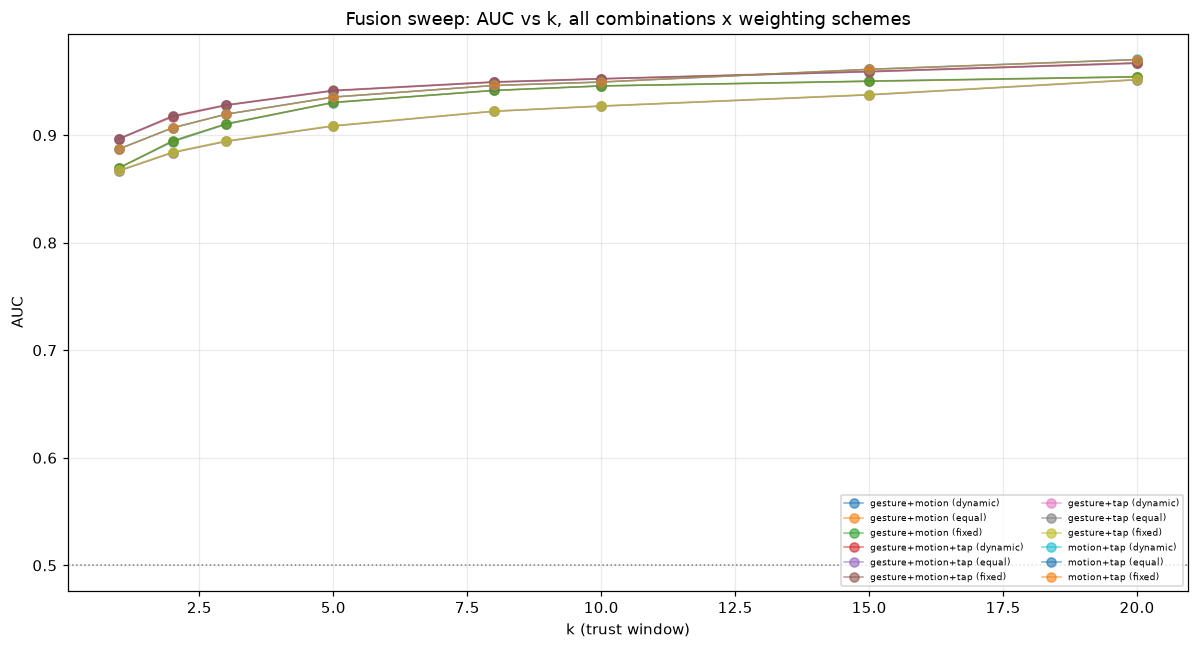

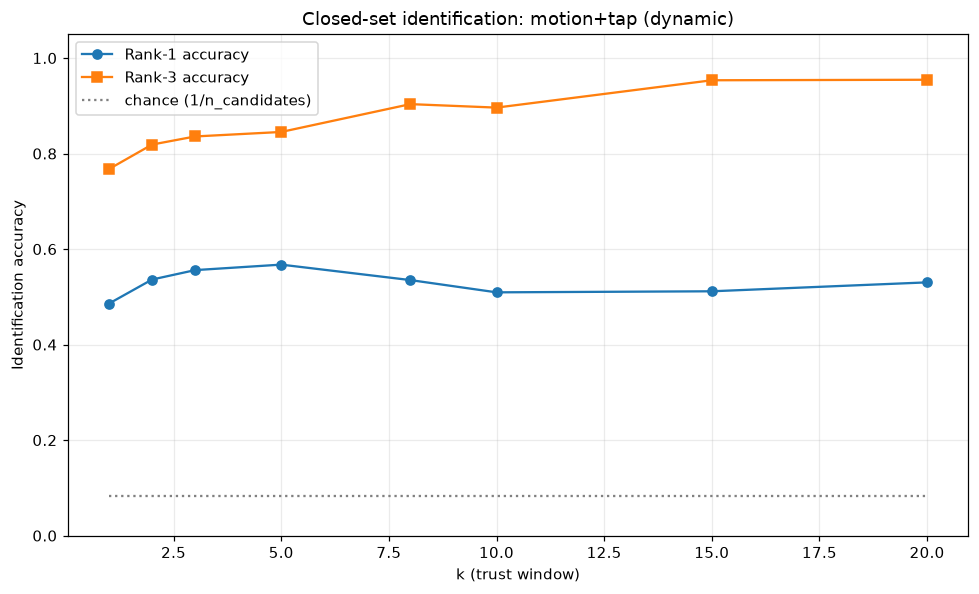

In [18]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(id_acc_df['k'], id_acc_df['rank1_accuracy'], marker='o', label='Rank-1 accuracy')
if id_acc_df['rank3_accuracy'].notna().any():
    ax.plot(id_acc_df['k'], id_acc_df['rank3_accuracy'], marker='s', label='Rank-3 accuracy')
ax.plot(id_acc_df['k'], id_acc_df['chance_rank1'], marker='', ls=':', color='gray',
        label='chance (1/n_candidates)')
ax.set_xlabel('k (trust window)'); ax.set_ylabel('Identification accuracy')
ax.set_ylim(0, 1.05)
ax.set_title(f'Closed-set identification: {"+".join(BEST_COMBO)} ({BEST_SCHEME})')
ax.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR / '02_identification_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


### 13b. Confusion matrix -- WHO gets mistaken for whom

At a representative k, which identities does the model actually confuse
with each other. This is diagnostic, not a headline number -- worth
checking whether confusions cluster around the pace-driven pairs already
suspected from the Gate 3 detour (fast vs. slow participants), or are
scattered without a clear pattern.


Confusion matrix at k=20 (rows=true identity, cols=predicted, values=fraction of that identity's trust windows predicted as each candidate):

predicted_pid  p3M6E7Z  p3YDMHG  p95MPVX  pAFQRTM  pH3S4X4  pNDG8LJ  pUNKH7L  pWS9VTN
true_pid                                                                             
p3M6E7Z           1.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
p3YDMHG           0.00     1.00     0.00     0.00     0.00     0.00     0.00     0.00
p95MPVX           0.00     0.00     1.00     0.00     0.00     0.00     0.00     0.00
pAFQRTM           0.00     0.00     0.00     0.06     0.00     0.00     0.94     0.00
pH3S4X4           0.00     0.00     0.00     0.00     0.00     1.00     0.00     0.00
pNDG8LJ           0.00     0.00     0.00     0.00     1.00     0.00     0.00     0.00
pUNKH7L           0.00     0.00     0.00     1.00     0.00     0.00     0.00     0.00
pWS9VTN           0.00     0.00     0.43     0.00     0.00     0.00     0.00     0.5

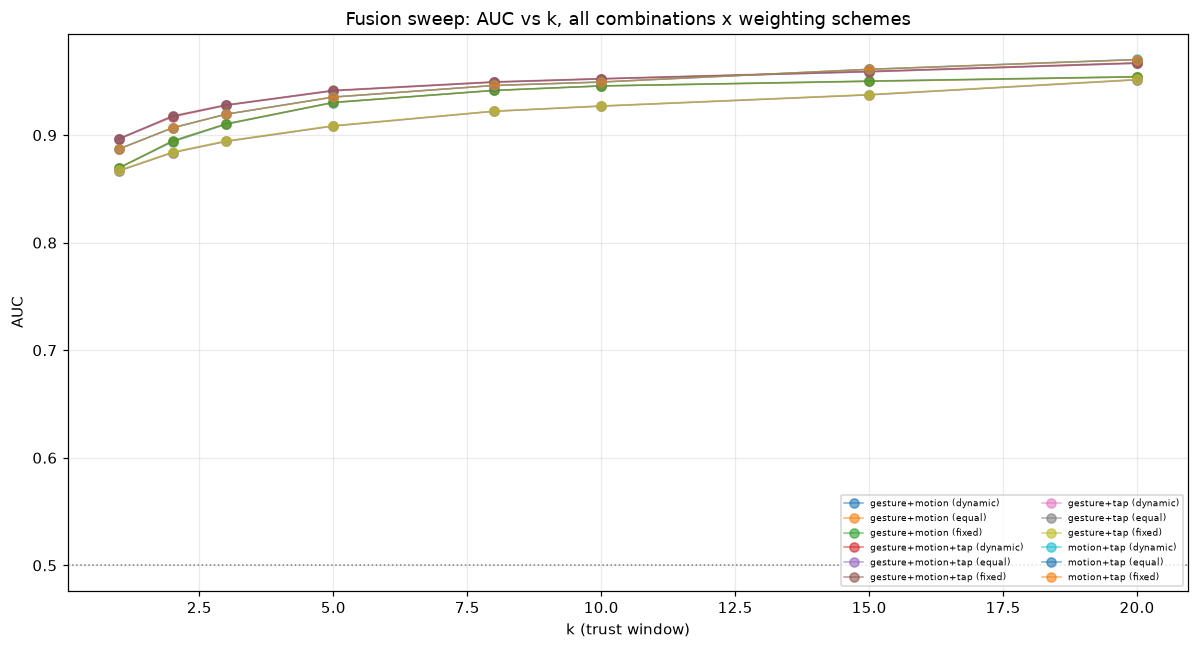

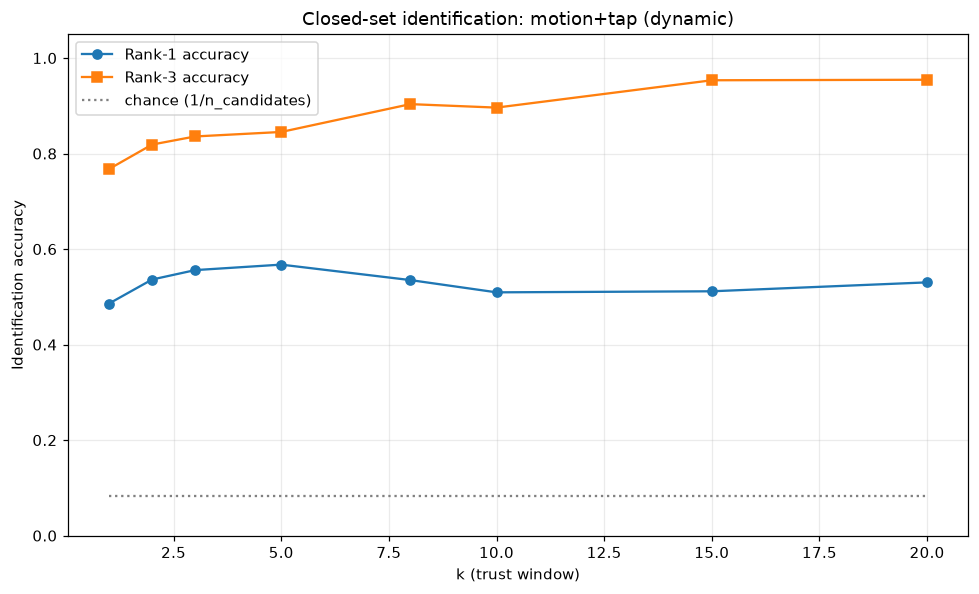

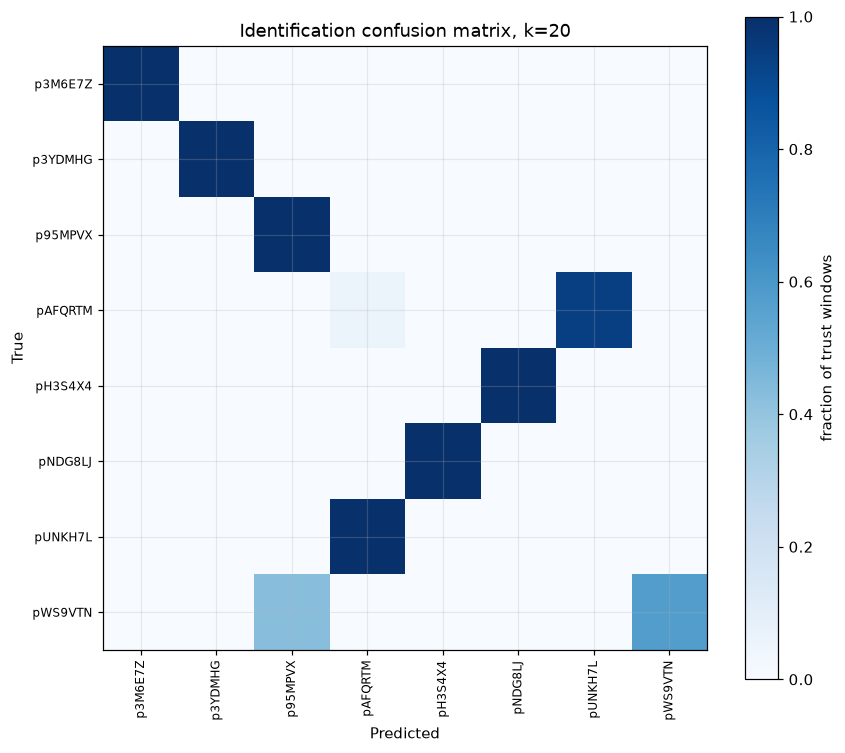

In [19]:
CONFUSION_K = 20

conf_data = best_combined_all[best_combined_all['k'] == CONFUSION_K]
if len(id_fixed_ids) >= 2:
    conf_data = conf_data[conf_data['pid'].isin(id_fixed_ids)]

if conf_data.empty:
    print(f"No data at k={CONFUSION_K} for the confusion matrix -- try a smaller k.")
else:
    predictions = []
    for trust_id, gt in conf_data.groupby('trust_id'):
        ranked = gt.sort_values('combined_z')
        predictions.append({'true_pid': gt['pid'].iloc[0], 'predicted_pid': ranked['cand'].iloc[0]})
    pred_df = pd.DataFrame(predictions)

    all_ids = sorted(set(pred_df['true_pid']) | set(pred_df['predicted_pid']))
    conf_matrix = pd.crosstab(pred_df['true_pid'], pred_df['predicted_pid']).reindex(
        index=all_ids, columns=all_ids, fill_value=0)
    conf_matrix_pct = conf_matrix.div(conf_matrix.sum(axis=1), axis=0).fillna(0)

    print(f"Confusion matrix at k={CONFUSION_K} (rows=true identity, cols=predicted, "
          f"values=fraction of that identity's trust windows predicted as each candidate):\n")
    print(conf_matrix_pct.to_string(float_format=lambda v: f'{v:.2f}'))

    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(conf_matrix_pct.values, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(all_ids))); ax.set_xticklabels(all_ids, rotation=90, fontsize=8)
    ax.set_yticks(range(len(all_ids))); ax.set_yticklabels(all_ids, fontsize=8)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'Identification confusion matrix, k={CONFUSION_K}')
    plt.colorbar(im, ax=ax, label='fraction of trust windows')
    plt.tight_layout()
    fig.savefig(PLOTS_DIR / '03_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    conf_matrix_pct.to_csv(OUT_DIR / 'identification_confusion_matrix.csv')


In [20]:
id_acc_df.to_csv(OUT_DIR / 'identification_accuracy.csv', index=False)
print(f"Wrote {OUT_DIR / 'identification_accuracy.csv'}")


Wrote ../data/processed/fusion_evaluation/identification_accuracy.csv


In [21]:
conf_data = best_combined_all[(best_combined_all['k']==20) & best_combined_all['pid'].isin(id_fixed_ids)]
for pid in ['pAFQRTM', 'pNDG8LJ', 'pUNKH7L', 'pWS9VTN']:
    g = conf_data[conf_data['pid']==pid]
    ranks = []
    for tid, gt in g.groupby('trust_id'):
        ranked = gt.sort_values('combined_z')['cand'].tolist()
        if pid in ranked:
            ranks.append(ranked.index(pid) + 1)
    print(f"{pid}: mean rank of true identity = {sum(ranks)/len(ranks):.1f} (n={len(ranks)})")

pAFQRTM: mean rank of true identity = 1.9 (n=17)
pNDG8LJ: mean rank of true identity = 2.0 (n=10)
pUNKH7L: mean rank of true identity = 4.0 (n=4)
pWS9VTN: mean rank of true identity = 1.8 (n=14)


In [22]:
CONFUSION_K = 20
conf_data_all = best_combined_all[best_combined_all['k'] == CONFUSION_K]  # no fixed-identity filter

predictions_all = []
for trust_id, gt in conf_data_all.groupby('trust_id'):
    ranked = gt.sort_values('combined_z')
    predictions_all.append({'true_pid': gt['pid'].iloc[0], 'predicted_pid': ranked['cand'].iloc[0]})
pred_df_all = pd.DataFrame(predictions_all)

all_ids_full = sorted(set(pred_df_all['true_pid']) | set(pred_df_all['predicted_pid']))
conf_matrix_full = pd.crosstab(pred_df_all['true_pid'], pred_df_all['predicted_pid']).reindex(
    index=all_ids_full, columns=all_ids_full, fill_value=0)
conf_matrix_full_pct = conf_matrix_full.div(conf_matrix_full.sum(axis=1), axis=0).fillna(0)
print(conf_matrix_full_pct.to_string(float_format=lambda v: f'{v:.2f}'))
print()
print("Your row specifically:")
print(conf_matrix_full_pct.loc['pG5G4MS'] if 'pG5G4MS' in conf_matrix_full_pct.index else "pG5G4MS still has no probe rows at k=20 -- try a smaller k")

predicted_pid  p3M6E7Z  p3YDMHG  p95MPVX  pAFQRTM  pEZVKTS  pH3S4X4  pNDG8LJ  pUNKH7L  pWS9VTN
true_pid                                                                                      
p3M6E7Z           1.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
p3YDMHG           0.00     1.00     0.00     0.00     0.00     0.00     0.00     0.00     0.00
p95MPVX           0.00     0.00     1.00     0.00     0.00     0.00     0.00     0.00     0.00
pAFQRTM           0.00     0.00     0.00     0.06     0.00     0.00     0.00     0.94     0.00
pEZVKTS           0.00     0.00     0.00     0.00     1.00     0.00     0.00     0.00     0.00
pH3S4X4           0.00     0.00     0.00     0.00     0.00     0.00     1.00     0.00     0.00
pNDG8LJ           0.00     0.00     0.00     0.00     0.00     1.00     0.00     0.00     0.00
pUNKH7L           0.00     0.00     0.00     1.00     0.00     0.00     0.00     0.00     0.00
pWS9VTN           0.00     0.00     0.43     0.00 

In [23]:
for k in K_VALUES:
    g = best_combined_all[(best_combined_all['k']==k) & (best_combined_all['pid']=='pG5G4MS')]
    print(f"k={k:2d}: {g['trust_id'].nunique()} trust windows as probe")

k= 1: 14 trust windows as probe
k= 2: 13 trust windows as probe
k= 3: 12 trust windows as probe
k= 5: 10 trust windows as probe
k= 8: 7 trust windows as probe
k=10: 5 trust windows as probe
k=15: 0 trust windows as probe
k=20: 0 trust windows as probe


In [24]:
for m in ['tap', 'gesture', 'motion']:
    probe_counts = dfs[m][dfs[m]['role']=='probe'].groupby('participantId').size().sort_values()
    print(f"{m}: pG5G4MS has {probe_counts.get('pG5G4MS', 0)} probe windows "
          f"(cohort median: {probe_counts.median():.0f}, cohort max: {probe_counts.max()})")

tap: pG5G4MS has 13 probe windows (cohort median: 24, cohort max: 69)
gesture: pG5G4MS has 13 probe windows (cohort median: 24, cohort max: 69)
motion: pG5G4MS has 14 probe windows (cohort median: 25, cohort max: 70)
